# 04 · Many-to-One in Practice — Classifying Multivariate Signals (a Consulting Workhorse)

The **many-to-one** RNN — read a whole sequence, emit **one label** — is the pattern behind a huge
share of real projects:

| Consulting problem | Sequence in | Label out |
|---|---|---|
| **Predictive maintenance** | last N seconds of vibration/current sensors | healthy / faulty (which fault) |
| **Customer churn** | a customer's recent activity events | will churn / won't |
| **Fraud detection** | sequence of transactions | fraudulent / legit |
| **Human activity recognition** | phone accelerometer window | walking / running / sitting |
| **Clinical** | an ECG heartbeat | normal / arrhythmia |

We'll build a realistic **predictive-maintenance classifier**: from a short window of a rotating
machine's **3 vibration sensors**, decide the operating state — **Healthy**, **Imbalance**, or
**Bearing fault**. This mirrors a very common industrial engagement.

You'll learn the full practical workflow:
1. Generate a labelled, **multivariate** (3-feature) time-series dataset.
2. Use PyTorch **`Dataset` / `DataLoader`** for proper mini-batch training.
3. Train an **LSTM classifier**, tracking train & validation accuracy.
4. Evaluate honestly with a **confusion matrix** and a **classification report**.
5. Discuss deployment realities (class imbalance, thresholds, drift).

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 1. A simple example first: what makes the 3 classes *different*?

Before any modeling, always **look at the data**. Our synthetic machine produces 3 vibration
channels (think sensors mounted on X, Y, Z axes). Each health state has a physically-motivated
signature:

- **Healthy** — smooth rotation: a clean low-amplitude tone.
- **Imbalance** — a heavy spot causes a strong once-per-revolution vibration: a big low-frequency
  sinusoid.
- **Bearing fault** — a cracked bearing produces periodic *impacts*: sharp high-frequency bursts.

We encode these differences so an RNN has a real pattern to learn (but with noise, so it's not
trivial). Let's generate one example of each and plot them.

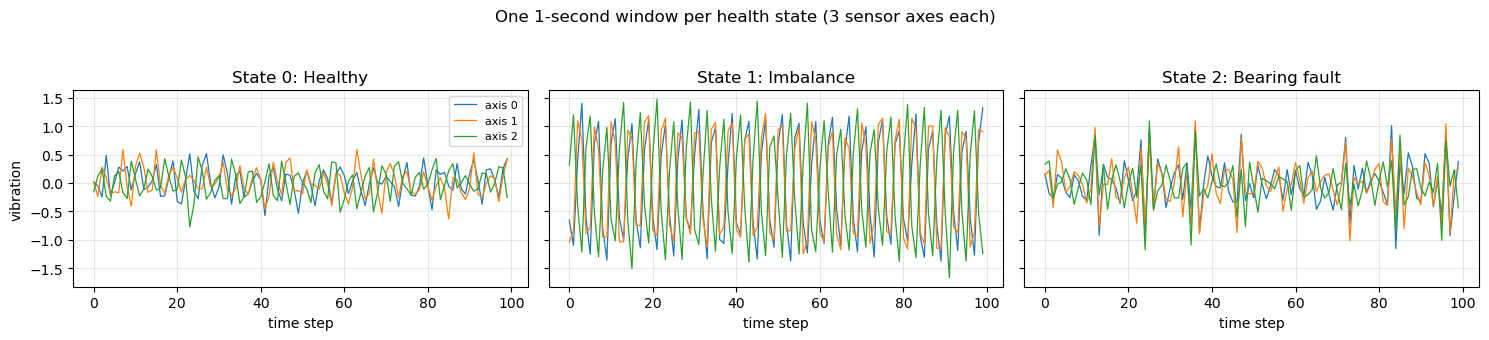

In [2]:
FS = 100          # samples per second (Hz)
WINDOW = 100      # 1 second window -> 100 time steps
N_FEATURES = 3    # 3 vibration axes

def generate_sample(state, window=WINDOW):
    '''Return a (window, 3) array of 3-axis vibration for a given machine state.'''
    t = np.arange(window) / FS
    base_freq = 25                                   # base rotation ~25 Hz
    x = np.zeros((window, N_FEATURES), dtype=np.float32)
    for axis in range(N_FEATURES):
        phase = np.random.uniform(0, 2 * np.pi)
        signal = 0.3 * np.sin(2 * np.pi * base_freq * t + phase)   # baseline rotation, all states

        if state == 1:   # IMBALANCE: strong low-freq component at the rotation frequency
            signal += 1.0 * np.sin(2 * np.pi * base_freq * t + phase)

        elif state == 2: # BEARING FAULT: periodic sharp impacts (high-freq bursts)
            impact_times = np.arange(0, window, 12)                # an impact every 12 samples
            for it in impact_times:
                burst = np.exp(-0.5 * ((np.arange(window) - it) / 1.5) ** 2)  # a spike envelope
                signal += 0.9 * burst * np.sin(2 * np.pi * 45 * t)           # ring at 45 Hz

        signal += 0.15 * np.random.randn(window)     # measurement noise
        x[:, axis] = signal
    return x

STATE_NAMES = ["Healthy", "Imbalance", "Bearing fault"]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.2), sharey=True)
for state, ax in enumerate(axes):
    sample = generate_sample(state)
    for axis in range(N_FEATURES):
        ax.plot(sample[:, axis], lw=0.9, label=f"axis {axis}")
    ax.set_title(f"State {state}: {STATE_NAMES[state]}")
    ax.set_xlabel("time step"); ax.grid(alpha=0.3)
axes[0].set_ylabel("vibration"); axes[0].legend(fontsize=8)
plt.suptitle("One 1-second window per health state (3 sensor axes each)", y=1.05)
plt.tight_layout(); plt.show()

## 2. Build the dataset

We create many labelled windows, then split into train / validation / test **by sample** (here it
is legitimate to shuffle, because each window is an *independent* recording — unlike the single
long series in notebook 02).

We also **standardize** the features (zero mean, unit variance) using statistics computed on the
**training set only**, then apply them to val/test. Fitting the scaler on all data would leak test
information — a subtle but important discipline.

In [3]:
def build_dataset(n_per_class=500):
    X, y = [], []
    for state in range(3):
        for _ in range(n_per_class):
            X.append(generate_sample(state))
            y.append(state)
    X = np.stack(X)                       # (N, WINDOW, 3)
    y = np.array(y, dtype=np.int64)       # (N,)
    # shuffle samples
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

X, y = build_dataset(n_per_class=500)
print("Full dataset X:", X.shape, "| y:", y.shape, "| classes:", np.bincount(y))

# split 70/15/15 by sample
n = len(X); n_tr, n_va = int(0.7 * n), int(0.85 * n)
X_tr, X_va, X_te = X[:n_tr], X[n_tr:n_va], X[n_va:]
y_tr, y_va, y_te = y[:n_tr], y[n_tr:n_va], y[n_va:]

# standardize using TRAIN statistics only (per feature/axis)
mean = X_tr.reshape(-1, N_FEATURES).mean(0)
std  = X_tr.reshape(-1, N_FEATURES).std(0)
def scale(a): return ((a - mean) / std).astype(np.float32)
X_tr, X_va, X_te = scale(X_tr), scale(X_va), scale(X_te)

print(f"train {len(X_tr)} | val {len(X_va)} | test {len(X_te)}")

Full dataset X: (1500, 100, 3) | y: (1500,) | classes: [500 500 500]
train 1050 | val 225 | test 225


In [4]:
# Wrap arrays in PyTorch Datasets and DataLoaders.
# A DataLoader hands us shuffled MINI-BATCHES automatically — the standard way to train.
def make_loader(Xa, ya, batch_size=64, shuffle=False):
    ds = TensorDataset(torch.tensor(Xa), torch.tensor(ya))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_tr, y_tr, shuffle=True)   # shuffle training order each epoch
val_loader   = make_loader(X_va, y_va)
test_loader  = make_loader(X_te, y_te)

xb, yb = next(iter(train_loader))
print("one mini-batch: X", tuple(xb.shape), "y", tuple(yb.shape))
print("(batch=64 windows, 100 time steps each, 3 features) -> 64 labels")

one mini-batch: X (64, 100, 3) y (64,)
(batch=64 windows, 100 time steps each, 3 features) -> 64 labels


## 3. The LSTM classifier

Design choices, each with a reason:

- **`nn.LSTM`** with `num_layers=2` — enough capacity to learn the impact/tone patterns.
- **`dropout`** between layers — light regularization to reduce overfitting.
- We take the **last time step's** hidden state (`out[:, -1, :]`) — the classic many-to-one
  read-out — and pass it through a small linear head to 3 class scores (logits).
- Loss is **`CrossEntropyLoss`**, the standard for multi-class classification (it expects raw
  logits, not softmax probabilities — a frequent beginner bug).

In [5]:
class VibrationClassifier(nn.Module):
    def __init__(self, n_features=3, hidden=64, n_layers=2, n_classes=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=n_layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, n_classes),          # -> raw logits (one score per class)
        )

    def forward(self, x):                       # x: (batch, time, features)
        out, (h_n, c_n) = self.lstm(x)          # LSTM returns hidden AND cell state
        last = out[:, -1, :]                    # final step summarizes the window
        return self.head(last)                  # (batch, n_classes)

model = VibrationClassifier().to(device)
print(model)
print("\ntrainable parameters:", sum(p.numel() for p in model.parameters()))

VibrationClassifier(
  (lstm): LSTM(3, 64, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)

trainable parameters: 53123


## 4. Train — with a proper validation loop

Now the training loop iterates over **mini-batches** and, at the end of each epoch, measures
**validation accuracy** on data the model didn't train on. Watching train vs. validation together
is how you detect **overfitting** (train keeps improving while validation stalls or worsens).

In [6]:
def evaluate(model, loader):
    '''Return (average loss, accuracy) over a loader — no gradient updates.'''
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += loss_fn(logits, yb).item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            total += len(yb)
    return total_loss / total, correct / total

def fit(model, train_loader, val_loader, epochs=12, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    hist = {"train_acc": [], "val_acc": []}
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:                 # <-- iterate mini-batches
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        tr_loss, tr_acc = evaluate(model, train_loader)
        va_loss, va_acc = evaluate(model, val_loader)
        hist["train_acc"].append(tr_acc); hist["val_acc"].append(va_acc)
        print(f"epoch {epoch+1:2d} | train acc {tr_acc:.3f} | val acc {va_acc:.3f}")
    return hist

hist = fit(model, train_loader, val_loader, epochs=12)

epoch  1 | train acc 0.337 | val acc 0.342


epoch  2 | train acc 0.565 | val acc 0.547


epoch  3 | train acc 0.679 | val acc 0.644


epoch  4 | train acc 0.679 | val acc 0.644


epoch  5 | train acc 0.679 | val acc 0.644


...

epoch  8 | train acc 0.663 | val acc 0.658


epoch  9 | train acc 0.679 | val acc 0.644


epoch 10 | train acc 0.663 | val acc 0.658


epoch 11 | train acc 0.679 | val acc 0.644


epoch 12 | train acc 0.663 | val acc 0.658


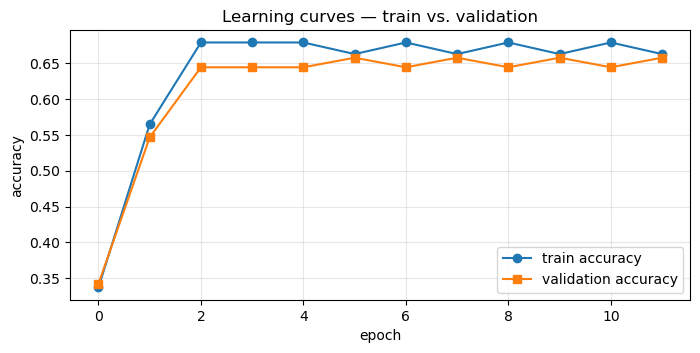

In [7]:
plt.figure(figsize=(8, 3.5))
plt.plot(hist["train_acc"], marker="o", label="train accuracy")
plt.plot(hist["val_acc"], marker="s", label="validation accuracy")
plt.title("Learning curves — train vs. validation")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5. Honest evaluation: confusion matrix & report on the untouched test set

Overall accuracy hides *which* mistakes a model makes. In predictive maintenance that matters a
lot: **missing a bearing fault** (predicting Healthy when it's faulty) is far more costly than a
false alarm. The **confusion matrix** shows exactly where errors land; the **classification
report** breaks out precision/recall/F1 per class.

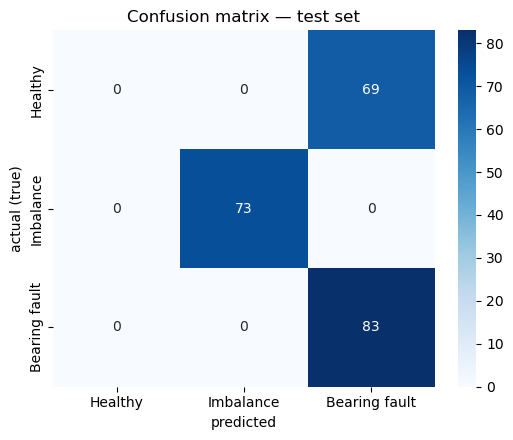

               precision    recall  f1-score   support

      Healthy      0.000     0.000     0.000        69
    Imbalance      1.000     1.000     1.000        73
Bearing fault      0.546     1.000     0.706        83

     accuracy                          0.693       225
    macro avg      0.515     0.667     0.569       225
 weighted avg      0.526     0.693     0.585       225



D:\Pablo_Data\Programas\miniconda3\envs\homl3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Pablo_Data\Programas\miniconda3\envs\homl3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
D:\Pablo_Data\Programas\miniconda3\envs\homl3\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(r

In [8]:
# collect predictions on the test set
model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(device)).argmax(1).cpu().numpy()
        all_pred.extend(preds); all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=STATE_NAMES, yticklabels=STATE_NAMES)
plt.xlabel("predicted"); plt.ylabel("actual (true)")
plt.title("Confusion matrix — test set")
plt.tight_layout(); plt.show()

print(classification_report(all_true, all_pred, target_names=STATE_NAMES, digits=3))

### How to read this like a consultant

- **Diagonal = correct.** Off-diagonal cells are the mistakes and their *direction*.
- **Recall of "Bearing fault"** answers *"of all real bearing faults, how many did we catch?"* —
  the safety-critical number in maintenance. You often **tune the decision threshold** to push
  this recall up, accepting a few more false alarms.
- **Precision of "Healthy"** answers *"when we say healthy, how often is it truly healthy?"* — the
  cost of complacency.

Which error you optimize for is a **business decision**, not a modeling one — surfacing that
trade-off is a big part of the value you add on an engagement.

## 6. From notebook to production — the realities

A model that scores well here still needs these before it's useful in the field:

- **Class imbalance.** Real faults are *rare*. Use `class_weight`/weighted loss, resampling
  (`imblearn`), and evaluate with **precision-recall / F1**, not raw accuracy (99% "Healthy"
  accuracy is worthless if it never catches a fault).
- **Windowing at inference.** In production you slide the window over a live stream and classify
  continuously; consider **majority-voting** over several consecutive windows to reduce jitter.
- **Concept drift.** Machines age, sensors are replaced, seasons change. Monitor input
  distributions and **retrain** when they drift.
- **Calibration & thresholds.** Turn logits into calibrated probabilities so a maintenance team
  can act on "78% chance of bearing fault" with a chosen alarm threshold.
- **Explainability.** Engineers trust models they understand — pair predictions with the salient
  signal features (e.g. the impact frequency) that drove them.

## 7. Recap & what's next

- Many-to-one = read a sequence → **one label**; it powers maintenance, churn, fraud, activity,
  clinical use cases.
- We built the full workflow: **multivariate** data, **`DataLoader`** mini-batches, an **LSTM**
  classifier, train/val curves, and a **confusion-matrix** evaluation that exposes business-
  relevant errors.

➡️ **Next:** `05_one_to_many_generation.ipynb` — flip the direction: from **one input to many
outputs**. We build an autoregressive character-level generator and learn *sampling*
(temperature), the mechanism behind all sequence generation.